# Paso 5 — Particionado del Conjunto de Datos
**Normalización | División 70/15/15 estratificada | SMOTE si hay desbalance**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

BASE_DIR  = os.path.abspath('..')
PROCESSED = os.path.join(BASE_DIR, 'dataset', 'processed')
MODELS    = os.path.join(BASE_DIR, 'models')
FIGURES   = os.path.join(BASE_DIR, 'docs', 'figures')
os.makedirs(MODELS, exist_ok=True)

df = pd.read_csv(os.path.join(PROCESSED, 'dataset_procesado.csv'))
PARAMS = ['pH', 'Turbidez', 'Temperatura']
print(f'Dataset cargado: {df.shape[0]:,} muestras')

Dataset cargado: 6,058 muestras


## 5.1 — Preparar X e y

In [2]:
X = df[PARAMS].values
y = df['ETIQUETA'].values

# Codificación numérica de etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Codificación de clases:')
for cls, cod in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls:12s} → {cod}')

joblib.dump(le, os.path.join(MODELS, 'label_encoder.pkl'))
print('\nLabelEncoder guardado.')

Codificación de clases:
  Alerta       → 0
  Contaminada  → 1
  Optima       → 2

LabelEncoder guardado.


## 5.2 — División estratificada 70% / 15% / 15%

In [3]:
# Primera división: 70% train | 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

# Segunda división: 50% del 30% → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

n_total = len(X)
print(f'Total:         {n_total:,} muestras (100%)')
print(f'Entrenamiento: {len(X_train):,} muestras ({len(X_train)/n_total*100:.1f}%)')
print(f'Validación:    {len(X_val):,} muestras ({len(X_val)/n_total*100:.1f}%)')
print(f'Prueba:        {len(X_test):,} muestras ({len(X_test)/n_total*100:.1f}%)')

print('\nBalance de clases por partición:')
for nombre, y_p in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_p, return_counts=True)
    desglose = {le.classes_[u]: c for u, c in zip(unique, counts)}
    print(f'  {nombre}: {desglose}')

Total:         6,058 muestras (100%)
Entrenamiento: 4,240 muestras (70.0%)
Validación:    909 muestras (15.0%)
Prueba:        909 muestras (15.0%)

Balance de clases por partición:
  Train: {'Alerta': np.int64(453), 'Contaminada': np.int64(3502), 'Optima': np.int64(285)}
  Val: {'Alerta': np.int64(97), 'Contaminada': np.int64(750), 'Optima': np.int64(62)}
  Test: {'Alerta': np.int64(97), 'Contaminada': np.int64(751), 'Optima': np.int64(61)}


## 5.3 — Normalización con StandardScaler

In [4]:
# IMPORTANTE: el scaler se ajusta SOLO con el conjunto de entrenamiento
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)
X_test_sc   = scaler.transform(X_test)

print('Estadísticas del scaler (calculadas en TRAIN):')
for param, mean, std in zip(PARAMS, scaler.mean_, scaler.scale_):
    print(f'  {param:12s}: media = {mean:.3f}, desv.std = {std:.3f}')

joblib.dump(scaler, os.path.join(MODELS, 'scaler.pkl'))
print('\nScaler guardado en models/scaler.pkl')

Estadísticas del scaler (calculadas en TRAIN):
  pH          : media = 7.215, desv.std = 0.712
  Turbidez    : media = 127.723, desv.std = 168.771
  Temperatura : media = 22.972, desv.std = 4.958

Scaler guardado en models/scaler.pkl


## 5.4 — Balance de clases con SMOTE (si es necesario)

In [5]:
unique, counts = np.unique(y_train, return_counts=True)
ratio = counts.min() / counts.max()

print(f'Distribución antes de SMOTE: {dict(zip(le.classes_, counts))}')
print(f'Ratio min/max: {ratio:.2f}')

if ratio < 0.6:
    print('\nAplicando SMOTE (desbalance > 40%)...')
    smote = SMOTE(random_state=42, k_neighbors=min(5, counts.min()-1))
    X_train_sc, y_train = smote.fit_resample(X_train_sc, y_train)
    unique, counts = np.unique(y_train, return_counts=True)
    print(f'Distribución después de SMOTE: {dict(zip(le.classes_, counts))}')
    print(f'Muestras de entrenamiento: {len(X_train_sc):,}')
else:
    print('\nNo se necesita SMOTE. Clases bien balanceadas.')

Distribución antes de SMOTE: {'Alerta': np.int64(453), 'Contaminada': np.int64(3502), 'Optima': np.int64(285)}
Ratio min/max: 0.08

Aplicando SMOTE (desbalance > 40%)...
Distribución después de SMOTE: {'Alerta': np.int64(3502), 'Contaminada': np.int64(3502), 'Optima': np.int64(3502)}
Muestras de entrenamiento: 10,506


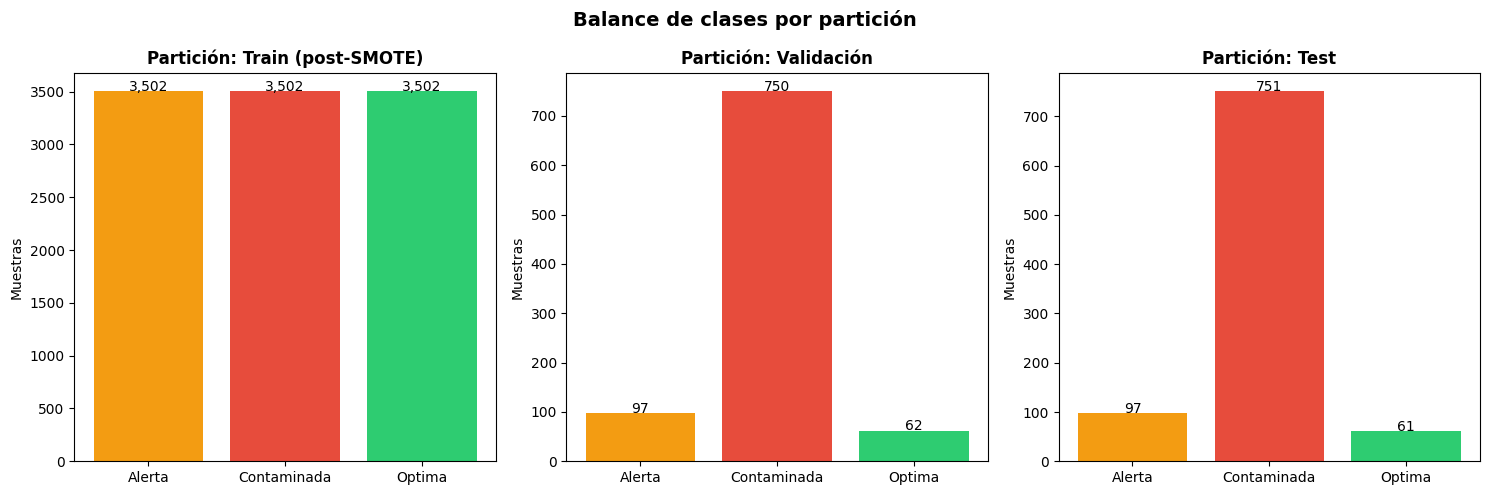

In [6]:
# Visualización de particiones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
PALETA = {'Optima': '#2ECC71', 'Alerta': '#F39C12', 'Contaminada': '#E74C3C'}

for ax, (nombre, y_p) in zip(axes, [('Train (post-SMOTE)', y_train),
                                      ('Validación', y_val),
                                      ('Test', y_test)]):
    unique, counts = np.unique(y_p, return_counts=True)
    clases  = [le.classes_[u] for u in unique]
    colores = [PALETA[c] for c in clases]
    ax.bar(clases, counts, color=colores)
    ax.set_title(f'Partición: {nombre}', fontweight='bold')
    ax.set_ylabel('Muestras')
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():,.0f}', ha='center', fontsize=10)

plt.suptitle('Balance de clases por partición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '04_particiones.png'), dpi=150)
plt.show()

## 5.5 — Guardar particiones en disco

In [7]:
np.save(os.path.join(PROCESSED, 'X_train.npy'), X_train_sc)
np.save(os.path.join(PROCESSED, 'X_val.npy'),   X_val_sc)
np.save(os.path.join(PROCESSED, 'X_test.npy'),  X_test_sc)
np.save(os.path.join(PROCESSED, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED, 'y_val.npy'),   y_val)
np.save(os.path.join(PROCESSED, 'y_test.npy'),  y_test)

print('Particiones guardadas en dataset/processed/')
print(f'  X_train: {X_train_sc.shape}   y_train: {y_train.shape}')
print(f'  X_val:   {X_val_sc.shape}     y_val:   {y_val.shape}')
print(f'  X_test:  {X_test_sc.shape}    y_test:  {y_test.shape}')

Particiones guardadas en dataset/processed/
  X_train: (10506, 3)   y_train: (10506,)
  X_val:   (909, 3)     y_val:   (909,)
  X_test:  (909, 3)    y_test:  (909,)
